# WeberElectrodynamics.jl — API showcase

This notebook lives alongside [`two_body_reference.ipynb`](two_body_reference.ipynb) and exercises API surfaces that the reference notebook does not touch:

1. **Custom Hamiltonian** built from `kinetic_term + coulomb_term` via the generic `HamiltonianSystem(H, q, p; …)` constructor (no Weber velocity term).
2. **Term introspection** — `term_names`, `has_term`, `get_term`, and the per-term `pair_decomposition` closure.
3. **Accessor tour** — `masses`, `charges`, `speed_of_light`, `params`, plus the shape accessors. Includes proof that `masses(prob)` is an O(1) view into `params(prob)`.
4. **3D lifted KS regularization** with the `:lifted_pair` backend.
5. **`CollisionBounce` callback** on its own — sub-critical like-charge oscillation in 2D.
6. **Combined regularization + bounce** — `RegularizedIntegrator` synthesises a `CollisionBounce` from the `collision_bounce_radius` kwarg, matching an explicit one bit-for-bit.
7. **Anchored 3-body custom Hamiltonian** in 3D — a middle particle oscillates on the `x = y = z` line while the two outer particles remain fixed, with trajectory and energy-error plots.

The plot cells require the optional `Plots` package.


In [1]:
using WeberElectrodynamics
using LinearAlgebra: norm
using Symbolics: @variables
using Printf: @printf


## 1 — Custom Hamiltonian: pure Coulomb (no Weber velocity term)

The generic `HamiltonianSystem(H, q_vars, p_vars; …)` constructor takes a pre-built symbolic Hamiltonian and compiles its equations of motion. We assemble `H = kinetic_term + coulomb_term` to integrate a 2-body Kepler orbit without the Weber velocity correction.


In [2]:
@variables x1 y1 x2 y2 px1 py1 px2 py2 m1 m2 qq1 qq2 cc tt
q_syms = [x1, y1, x2, y2]
p_syms = [px1, py1, px2, py2]

H_pure_coulomb =
    kinetic_term(p_syms; masses = [m1, m2], n_particles = 2, dims = 2) +
    coulomb_term(q_syms; charges = [qq1, qq2], n_particles = 2, dims = 2)

sys_coulomb = HamiltonianSystem(
    H_pure_coulomb,
    q_syms,
    p_syms;
    param_symbols = [m1, m2, qq1, qq2, cc],   # `cc` unused but the params layout requires it
    t = tt,
    n_particles = 2,
    dims = 2,
)
sys_coulomb.hamiltonian_symbolic

(qq1*qq2) / sqrt((x1 - x2)^2 + (y1 - y2)^2) + (px1^2 + py1^2) / (2m1) + (px2^2 + py2^2) / (2m2)

In [3]:
# Bound elliptic orbit: m1=m2=1, q1q2=-1 (attractive). Sub-circular tangential
# velocity gives a mild ellipticity. Period derived analytically.
m1_v, m2_v = 1.0, 1.0
q1_v, q2_v = 1.0, -1.0
r0 = 2.0
M = m1_v + m2_v
μ_red = m1_v * m2_v / M
v_circ = sqrt(abs(q1_v * q2_v) / (μ_red * r0))
v_init = 0.95 * v_circ
q0 = [-m2_v / M * r0, 0.0, m1_v / M * r0, 0.0]
p0 = [0.0, m1_v * (-m2_v / M * v_init), 0.0, m2_v * (m1_v / M * v_init)]
E_keplerian =
    0.5 * (sum(p0[1:2] .^ 2) / m1_v + sum(p0[3:4] .^ 2) / m2_v) + q1_v * q2_v / r0
k_kepler = -q1_v * q2_v
a_kepler = k_kepler / (-2 * E_keplerian)
T_kepler = 2π * sqrt(μ_red * a_kepler^3 / k_kepler)

prob_coulomb = HamiltonianProblem(
    sys_coulomb,
    (0.0, T_kepler),
    q0,
    p0;
    masses = [m1_v, m2_v],
    charges = [q1_v, q2_v],
    c = 1.0,
    dt = T_kepler / 10_000,
)
sol_coulomb = solve(prob_coulomb)
@printf "retcode=%s  steps=%d  closing offset Δq=%.2e\n" sol_coulomb.retcode length(
    sol_coulomb.t,
) maximum(abs, sol_coulomb.q[end] .- q0)

retcode=Success  steps=10001  closing offset Δq=7.21e-07


## 2 — Term introspection

The default `HamiltonianSystem(n, dims)` exposes a single named `:weber` term carrying two closures used by the energy statistics: `pair_decomposition(q, p, params)`, returning per-pair vectors in `pair_indices` order, and `kinetic_energy(q, p, params)`, returning the **physical** kinetic energy `Σ ½ mᵢ|vᵢ|²`.

Both take the whole state rather than a single pair, because recovering physical velocities from canonical momenta is one coupled solve over all pairs. A custom term may attach any compatible closures.

In [4]:
sys_default = HamiltonianSystem(2, 2)
@printf "term_names(sys)  = %s\n" term_names(sys_default)
@printf "has_term(:weber) = %s\n" has_term(sys_default, :weber)
@printf "has_symbolic_hamiltonian = %s\n" has_symbolic_hamiltonian(sys_default)

prob_default = HamiltonianProblem(
    sys_default,
    (0.0, 0.5),
    [1.0, 0.0, -1.0, 0.0],
    [0.05, 0.2, -0.05, -0.2];
    masses = [1.0, 1.0],
    charges = [1.0, -1.0],
    c = 5.0,
    dt = 0.005,
)
weber = get_term(sys_default, :weber)
decomp = weber.pair_decomposition(
    prob_default.q_initial,
    prob_default.p_initial,
    params(prob_default),
)
for (a, (i, j)) in enumerate(pair_indices(sys_default))
    @printf "Weber pair (%d,%d) at IC:  coulomb=%.4e  velocity=%.4e  r=%.3f  rdot=%.4e\n" i j decomp.coulomb[a] decomp.velocity[a] decomp.r[a] decomp.rdot[a]
end

# Physical kinetic energy differs from the canonical split once rdot != 0.
KE_phys = weber.kinetic_energy(
    prob_default.q_initial, prob_default.p_initial, params(prob_default),
)
KE_naive = sum(prob_default.p_initial .^ 2 ./ 2)
@printf "\nphysical KE = %.6f   Sum|p|^2/(2m) = %.6f\n" KE_phys KE_naive

term_names(sys)  = [:weber]
has_term(:weber) = true


has_symbolic_hamiltonian = false
Weber pair (1,2) at IC:  coulomb=-5.0000e-01  velocity=9.2456e-05  r=2.000  rdot=9.6154e-02



physical KE = 0.042311   Sum|p|^2/(2m) = 0.042500


## 3 — Accessor tour

Every public accessor on a `HamiltonianProblem`. The proof at the bottom shows `masses(prob)` aliases `params(prob)` (it is an O(1) view, not a copy).

In [5]:
@printf "n_particles(prob) = %d\n" n_particles(prob_default)
@printf "dims(prob)        = %d\n" dims(prob_default)
@printf "masses(prob)      = %s\n" string(collect(masses(prob_default)))
@printf "charges(prob)     = %s\n" string(collect(charges(prob_default)))
@printf "speed_of_light    = %g\n" speed_of_light(prob_default)
@printf "params(prob)      = %s\n" string(params(prob_default))
@printf "\nparent(masses(prob)) === params(prob)  → %s   (O(1) view, not a copy)\n" (
    parent(masses(prob_default)) === params(prob_default)
)


n_particles(prob) = 2
dims(prob)        = 2
masses(prob)      = [1.0, 1.0]
charges(prob)     = [1.0, -1.0]


speed_of_light    = 5
params(prob)      = [1.0, 1.0, 1.0, -1.0, 5.0]

parent(masses(prob)) === params(prob)  → true   (O(1) view, not a copy)


## 4 — 3D lifted KS regularization with `:lifted_pair`

The `:lifted_pair` backend uses a dimension-specific chart: square-root in 1D, Levi-Civita in 2D, and KS in 3D. This cell exercises the 3D KS pair path on a 2-body close approach.

The regularization diagnostics on the returned solution count activations, substeps, and the closest encounter.

In [6]:
sys_3d = HamiltonianSystem(2, 3)
m1_3d, m2_3d = 1.0, 0.1
q1_3d, q2_3d = sqrt(0.1), -sqrt(0.1)
c_3d = 4.0
r0_3d = 2.0
M_3d = m1_3d + m2_3d
v_circ_3d = sqrt(abs(q1_3d * q2_3d) * M_3d / (m1_3d * m2_3d * r0_3d))
v_3d = 0.5 * v_circ_3d
q0_3d = [-m2_3d / M_3d * r0_3d, 0.0, 0.0, m1_3d / M_3d * r0_3d, 0.0, 0.0]
p0_3d = [
    0.0,
    m1_3d * (-m2_3d / M_3d * v_3d),
    0.0,
    0.0,
    m2_3d * (m1_3d / M_3d * v_3d),
    0.0,
]
prob_3d = HamiltonianProblem(
    sys_3d,
    (0.0, 8.0),
    q0_3d,
    p0_3d;
    masses = [m1_3d, m2_3d],
    charges = [q1_3d, q2_3d],
    c = c_3d,
    dt = 2e-3,
)
alg_3d = RegularizedIntegrator(
    SymmetricProjectionIntegrator();
    backend = :lifted_pair,
    r_on_factor = 0.3,
    r_off_factor = 0.45,
    warn_on_fallback = false,
)
sol_3d = solve(prob_3d, alg_3d)
diag = sol_3d.regularization
@printf "retcode=%s  steps=%d\n" sol_3d.retcode length(sol_3d.t)
@printf "used_backend       = %s\n" diag.used_backend
@printf "activation_count   = %d\n" diag.activation_count
@printf "active_steps       = %d\n" diag.active_steps
@printf "total_substeps     = %d\n" diag.total_substeps
@printf "min encounter dist = %.3e\n" diag.min_encounter_distance
@printf "KS projections     = %d\n" diag.ks_constraint_projection_count
@printf "max KS constraint  = %.3e\n" diag.max_constraint_violation

retcode=Success  steps=4001
used_backend       = lifted_pair


activation_count   = 1
active_steps       = 543
total_substeps     = 4843
min encounter dist = 2.857e-01
KS projections     = 4158
max KS constraint  = 0.000e+00


## 5 — `CollisionBounce` callback on a sub-critical like-charge oscillation

Frauenfelder–Weber sub-critical regime: like-sign charges fall in through near-zero separation (Weber's velocity term overcomes Coulomb repulsion). The `CollisionBounce(r)` pre-step callback reflects the relative coordinate when the pair separation drops below `r`, providing a $C^0$ continuation of the head-on (ℓ = 0) collision (Frauenfelder & Weber 2024).

The validated parameters use absolute `dt = 1e-4` (not period-scaled) with `bounce_r = 0.02`, giving bounded global energy drift over long runs. We run 3 periods here.

In [7]:
m_b = 1.0
q_b = 1.0       # like charges
c_b = 4.0
r0_b = 0.05
mu_b = m_b * m_b / (m_b + m_b)
rho_b = q_b * q_b / (mu_b * c_b^2)
T_b = (2π / c_b) * rho_b
sys_b = HamiltonianSystem(2, 2)
prob_b = HamiltonianProblem(
    sys_b,
    (0.0, 3 * T_b),
    [r0_b / 2, 0.0, -r0_b / 2, 0.0],
    zeros(4);
    masses = [m_b, m_b],
    charges = [q_b, q_b],
    c = c_b,
    dt = 1e-4,
)
sol_b = solve(prob_b, SymmetricProjectionIntegrator(); callbacks = CollisionBounce(0.02))
en_b = compute_energy_timeseries(sol_b)
@printf "retcode=%s  steps=%d\n" sol_b.retcode length(sol_b.t)
@printf "max global energy drift = %.3e %%\n" abs(en_b.statistics.global_error_percent_max)

retcode=Success  steps=5892
max global energy drift = 1.043e-02 %


## 6 — `collision_bounce_radius` synthesises a CollisionBounce automatically

When a `RegularizedIntegrator` is constructed with `collision_bounce_radius > 0`, it synthesises an equivalent `CollisionBounce` callback at `init` time — unless the user already passed one via `callbacks=…`. The trajectories are bit-identical.

In [8]:
alg_synth = RegularizedIntegrator(
    SymmetricProjectionIntegrator();
    backend = :adaptive_cartesian,
    r_on = 0.001,
    r_off = 0.002,
    warn_on_fallback = false,
    collision_bounce_radius = 0.02,
)
integrator = init(prob_b, alg_synth)
@printf "integrator.callbacks length            = %d\n" length(integrator.callbacks)
@printf "integrator.callbacks[1] isa CollisionBounce = %s\n" (
    integrator.callbacks[1] isa CollisionBounce
)
@printf "integrator.callbacks[1].radius        = %g\n" integrator.callbacks[1].radius

alg_explicit = RegularizedIntegrator(
    SymmetricProjectionIntegrator();
    backend = :adaptive_cartesian,
    r_on = 0.001,
    r_off = 0.002,
    warn_on_fallback = false,
)
sol_synth = solve(prob_b, alg_synth)
sol_explicit = solve(prob_b, alg_explicit; callbacks = CollisionBounce(0.02))
max_dq = maximum(
    maximum(abs, sol_synth.q[i] .- sol_explicit.q[i]) for i in eachindex(sol_synth.q)
)
max_dp = maximum(
    maximum(abs, sol_synth.p[i] .- sol_explicit.p[i]) for i in eachindex(sol_synth.p)
)
@printf "\nbit-exact match against explicit CollisionBounce:\n"
@printf "  max|Δq| = %.2e\n" max_dq
@printf "  max|Δp| = %.2e\n" max_dp

integrator.callbacks length            = 1
integrator.callbacks[1] isa CollisionBounce = true
integrator.callbacks[1].radius        = 0.02

bit-exact match against explicit CollisionBounce:


  max|Δq| = 0.00e+00
  max|Δp| = 0.00e+00


## 7 — Anchored 3-body custom Hamiltonian in 3D

This example is physically one-dimensional but represented as a 3D Hamiltonian. All three particles start on the `x = y = z` line. The first and third particles are anchors: their momenta are omitted from `H`, so Hamilton's equations give `dq₁/dt = dq₃/dt = 0`. The middle particle has a harmonic potential to both anchors and starts slightly off center, so it oscillates along the same line.

The spring stiffness is passed through the first charge slot to stay inside the public `HamiltonianProblem` parameter layout `[masses; charges; c]`; in this custom system those charge slots are just user parameters, not electrostatic charges.

In [9]:
@variables xa1 ya1 za1 xm ym zm xa3 ya3 za3
@variables pxa1 pya1 pza1 pxm pym pzm pxa3 pya3 pza3
@variables ma1 mmid ma3 k_anchor unused_charge2 unused_charge3 cc_anchor tt_anchor

q_anchor_syms = [xa1, ya1, za1, xm, ym, zm, xa3, ya3, za3]
p_anchor_syms = [pxa1, pya1, pza1, pxm, pym, pzm, pxa3, pya3, pza3]

q_left_anchor = q_anchor_syms[1:3]
q_middle = q_anchor_syms[4:6]
q_right_anchor = q_anchor_syms[7:9]
p_middle = p_anchor_syms[4:6]

r_left_sq = sum((q_middle .- q_left_anchor) .^ 2)
r_right_sq = sum((q_middle .- q_right_anchor) .^ 2)

H_anchor =
    sum(p_middle .^ 2) / (2 * mmid) +
    k_anchor / 2 * (r_left_sq + r_right_sq)

sys_anchor = HamiltonianSystem(
    H_anchor,
    q_anchor_syms,
    p_anchor_syms;
    param_symbols = [ma1, mmid, ma3, k_anchor, unused_charge2, unused_charge3, cc_anchor],
    t = tt_anchor,
    n_particles = 3,
    dims = 3,
)
sys_anchor.hamiltonian_symbolic

(pxm^2 + pym^2 + pzm^2) / (2mmid) + (1//2)*k_anchor*((-xa1 + xm)^2 + (-xa3 + xm)^2 + (-ya1 + ym)^2 + (-ya3 + ym)^2 + (-za1 + zm)^2 + (-za3 + zm)^2)

In [10]:
anchor_distance = 1.0
middle_offset = 0.2
anchor_stiffness = 1.0
middle_mass = 1.0
ω_anchor = sqrt(2 * anchor_stiffness / middle_mass)
T_anchor = 2π / ω_anchor

q0_anchor = [
    -anchor_distance, -anchor_distance, -anchor_distance,
    middle_offset, middle_offset, middle_offset,
    anchor_distance, anchor_distance, anchor_distance,
]
p0_anchor = zeros(9)

prob_anchor = HamiltonianProblem(
    sys_anchor,
    (0.0, 4 * T_anchor),
    q0_anchor,
    p0_anchor;
    masses = [1.0, middle_mass, 1.0],
    charges = [anchor_stiffness, 0.0, 0.0],
    c = 1.0,
    dt = T_anchor / 500,
)

sol_anchor = solve(prob_anchor)
energy_anchor = compute_energy_timeseries(sol_anchor)

anchor_ids = [1, 2, 3, 7, 8, 9]
anchor_drift = maximum(
    maximum(abs, q[anchor_ids] .- q0_anchor[anchor_ids]) for q in sol_anchor.q
)
line_error = maximum(maximum(abs, q[4:6] .- q[4]) for q in sol_anchor.q)
middle_x = getindex.(sol_anchor.q, 4)
relative_energy_error = abs.(
    (energy_anchor.total_energy .- energy_anchor.total_energy[1]) ./
    energy_anchor.total_energy[1]
)

@printf "retcode=%s  steps=%d\n" sol_anchor.retcode length(sol_anchor.t)
@printf "anchor drift                  = %.3e\n" anchor_drift
@printf "middle off x=y=z line        = %.3e\n" line_error
@printf "middle x range               = [%.3f, %.3f]\n" minimum(middle_x) maximum(middle_x)
@printf "max relative energy error   = %.3e\n" maximum(relative_energy_error)

retcode=Success  steps=2001
anchor drift                  = 0.000e+00


middle off x=y=z line        = 0.000e+00
middle x range               = [-0.200, 0.200]
max relative energy error   = 5.124e-15


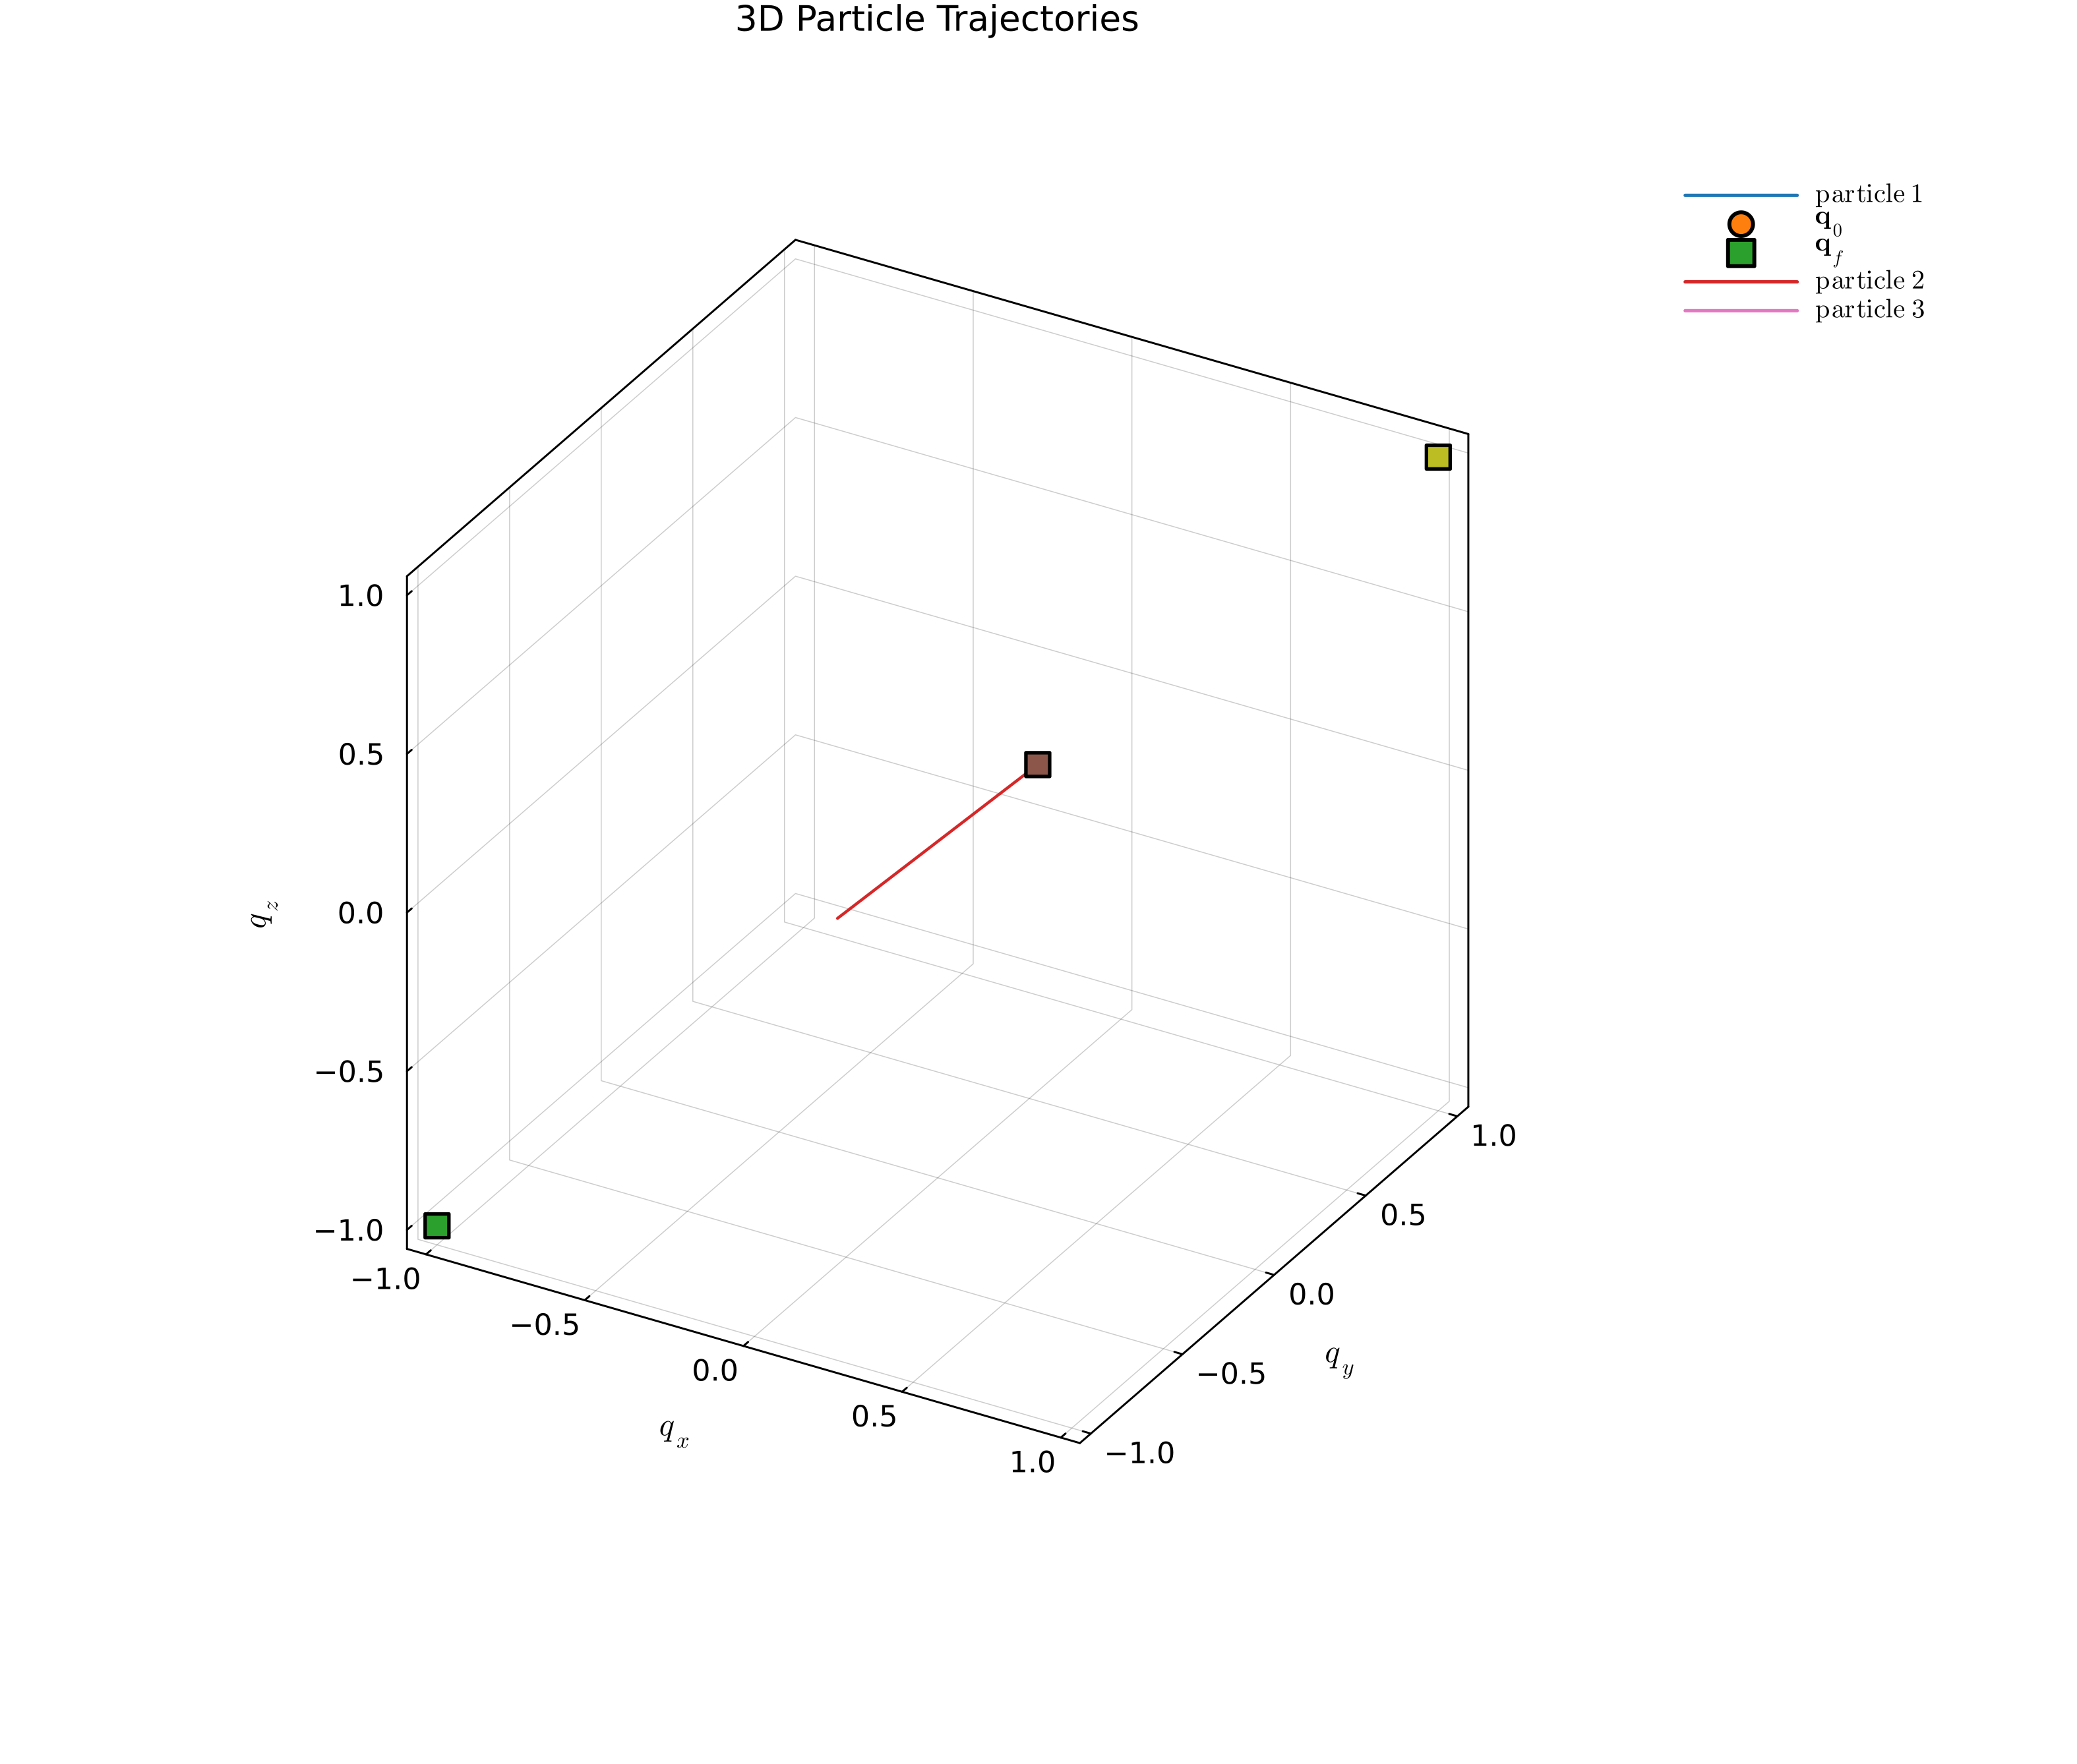

In [11]:
using Plots

trajectory_anchor = compute_trajectory_data(sol_anchor; stride = 5)
plot_trajectories(trajectory_anchor)

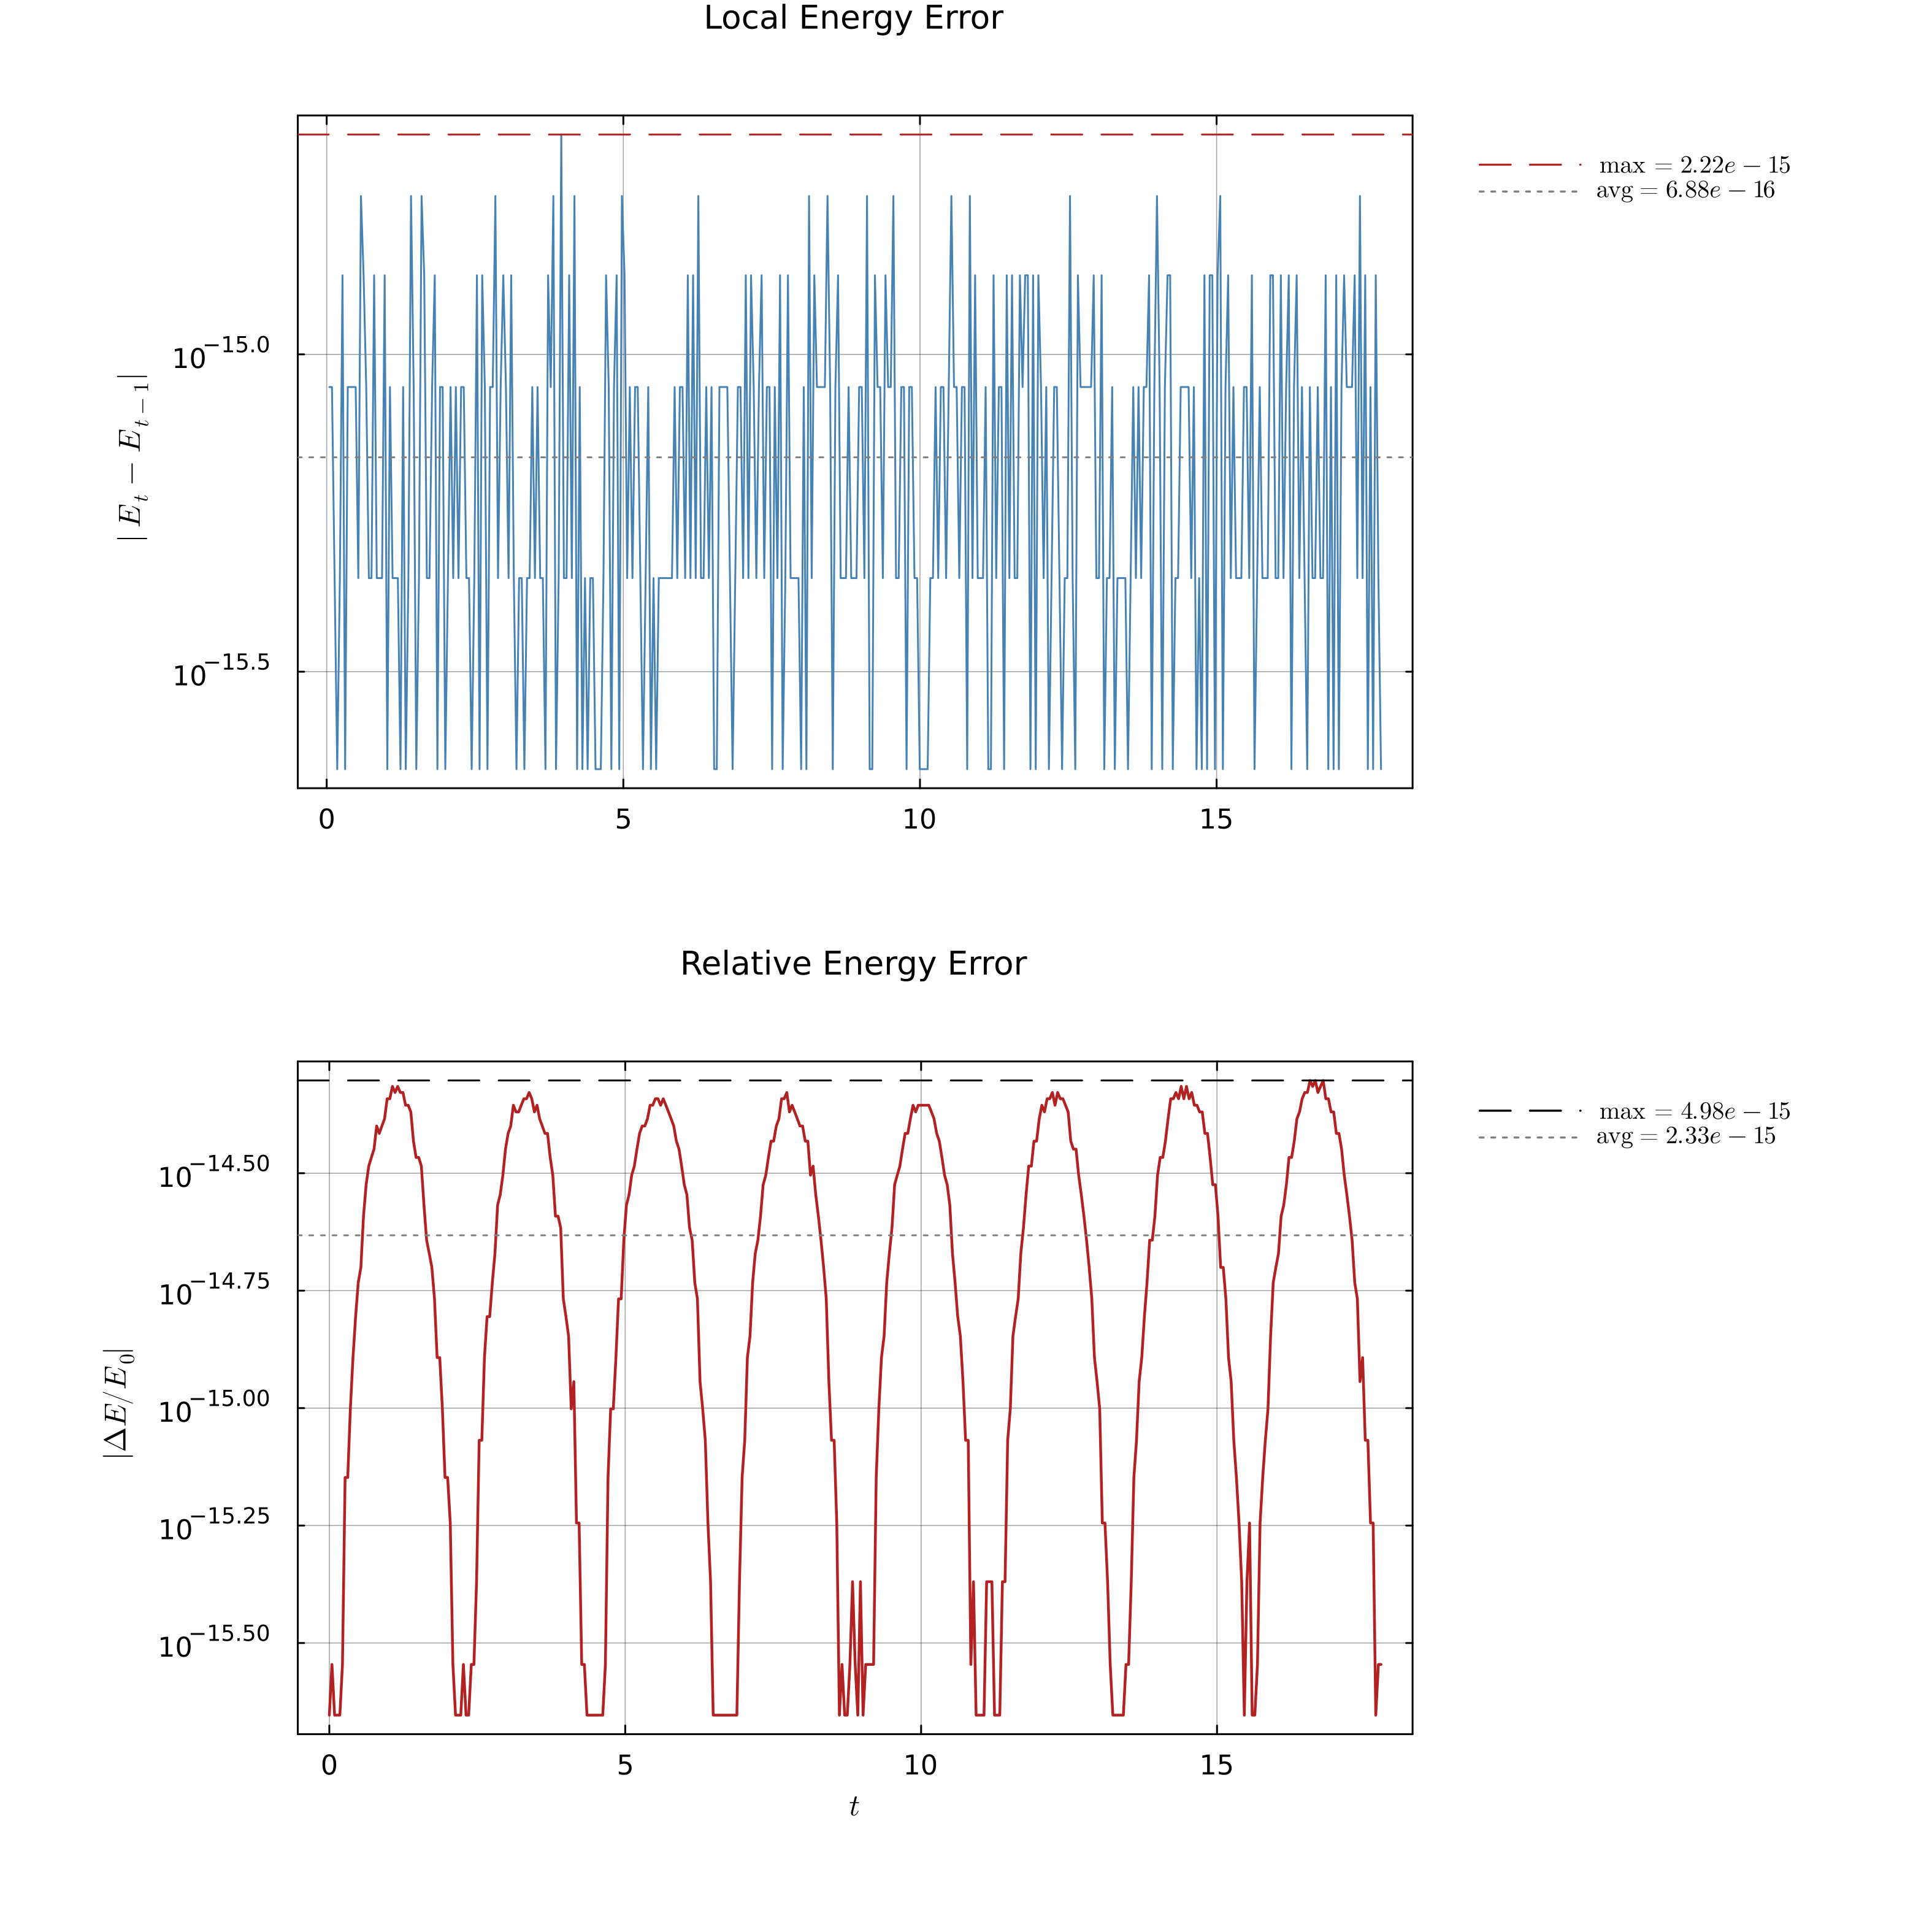

In [12]:
energy_anchor_plot = compute_energy_timeseries(sol_anchor; stride = 5)
plot_energy_errors(energy_anchor_plot)